# Neuron Model

## [Transfer Functions](https://engineer-e.github.io/Neural-Network/Neural_Network_Design_2e/Ch2/theory_and_examples/neuron_model/transfer_function.html)

1. The transfer function in *Figure 2.1* way be a linear or a non linear function of *n*. 
2. A particular transfer function is chosen to satisfy some specification of the problem that the neuron is attempting to solve. 
3. A variety of transfer function have been included in this book. 
4. Three of the most commonly used functions are discussed below.
   - Hard Limit Transfer Function
   - Linear Transfer Function
   - Log-Sigmoid Transfer Function

### Hard Limit Transfer Function

1. The *hard limit transfer function*, shown on the left side of Figure 2.2, sets the output of the neuron to 0. If the function argument is less than 0, or 1 if its arguments is greater than or equal to 0.

$$ \displaystyle \mathbb{Hard\enspace Limit \enspace Transfer \enspace Function } = \begin{cases}
   0 &\text{if } n < 0 \\
   1 &\text{if } n ≥ 0
\end{cases}$$

2. We will use this function to create neurons that classify inputs into two distinct categories. 
3. It will be extensively in Chapter 4.

#### Figure 2.2 Hard Limit Transfer Function

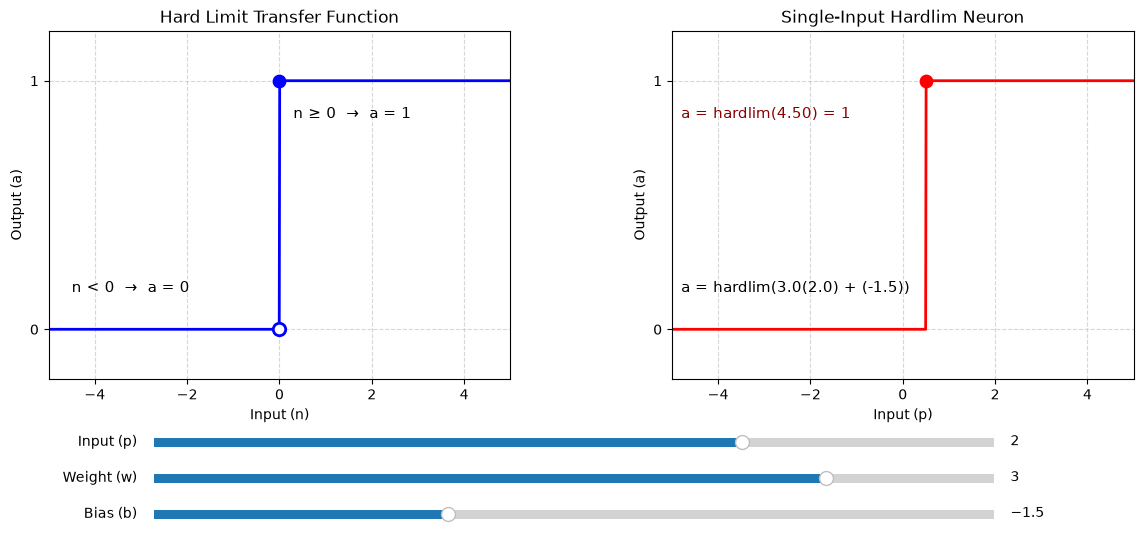

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# ============================================================
# Hard Limit Transfer Function
# ============================================================

n = np.linspace(-5, 5, 1000)
a = np.where(n < 0, 0, 1)

# Initial values
p0 = 2.0
w0 = 3.0
b0 = -1.5

# ============================================================
# Create Figure
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Leave space at bottom for sliders
plt.subplots_adjust(bottom=0.30, wspace=0.35)

# ============================================================
# CHART 1: Hard Limit Transfer Function
# ============================================================

ax1.plot(n, a, color="blue", linewidth=2)

# Open circle at (0,0)
ax1.scatter(
    0, 0,
    facecolors="white",
    edgecolors="blue",
    s=80,
    linewidth=2,
    zorder=5
)

# Filled circle at (0,1)
ax1.scatter(
    0, 1,
    color="blue",
    s=80,
    zorder=5
)

ax1.set_title("Hard Limit Transfer Function")
ax1.set_xlabel("Input (n)")
ax1.set_ylabel("Output (a)")
ax1.set_xlim(-5, 5)
ax1.set_ylim(-0.2, 1.2)
ax1.set_yticks([0, 1])
ax1.grid(True, linestyle="--", alpha=0.5)

ax1.text(-4.5, 0.15, "n < 0  →  a = 0", fontsize=11)
ax1.text(0.3, 0.85, "n ≥ 0  →  a = 1", fontsize=11)

# ============================================================
# CHART 2: Single-Input Hardlim Neuron
# ============================================================

p = np.linspace(-5, 5, 1000)

net = w0 * p + b0
output = np.where(net < 0, 0, 1)

line2, = ax2.plot(
    p,
    output,
    color="red",
    linewidth=2
)

# Threshold
threshold = -b0 / w0

threshold_point = ax2.scatter(
    threshold,
    1,
    color="red",
    s=80,
    zorder=5
)

ax2.set_title("Single-Input Hardlim Neuron")
ax2.set_xlabel("Input (p)")
ax2.set_ylabel("Output (a)")
ax2.set_xlim(-5, 5)
ax2.set_ylim(-0.2, 1.2)
ax2.set_yticks([0, 1])
ax2.grid(True, linestyle="--", alpha=0.5)

# Equation text
equation_text = ax2.text(
    -4.8,
    0.15,
    "",
    fontsize=11
)

output_text = ax2.text(
    -4.8,
    0.85,
    "",
    fontsize=11,
    color="darkred"
)

# ============================================================
# SLIDERS
# ============================================================

# Input slider
ax_p = plt.axes([0.20, 0.18, 0.60, 0.03])
slider_p = Slider(
    ax=ax_p,
    label="Input (p)",
    valmin=-5,
    valmax=5,
    valinit=p0,
    valstep=0.1
)

# Weight slider
ax_w = plt.axes([0.20, 0.12, 0.60, 0.03])
slider_w = Slider(
    ax=ax_w,
    label="Weight (w)",
    valmin=-5,
    valmax=5,
    valinit=w0,
    valstep=0.1
)

# Bias slider
ax_b = plt.axes([0.20, 0.06, 0.60, 0.03])
slider_b = Slider(
    ax=ax_b,
    label="Bias (b)",
    valmin=-5,
    valmax=5,
    valinit=b0,
    valstep=0.1
)

# ============================================================
# UPDATE FUNCTION
# ============================================================

def update(val):

    # Get slider values
    p_value = slider_p.val
    w_value = slider_w.val
    b_value = slider_b.val

    # Calculate net input
    net_value = w_value * p_value + b_value

    # Hard limit activation
    output_value = 0 if net_value < 0 else 1

    # Update neuron graph
    net_graph = w_value * p + b_value
    output_graph = np.where(net_graph < 0, 0, 1)

    line2.set_ydata(output_graph)

    # Update threshold
    if w_value != 0:
        threshold = -b_value / w_value
        threshold = np.clip(threshold, -5, 5)

        threshold_point.set_offsets(
            [[threshold, 1]]
        )

    # Update equation
    equation_text.set_text(
        f"a = hardlim({w_value:.1f}({p_value:.1f}) + ({b_value:.1f}))"
    )

    output_text.set_text(
        f"a = hardlim({net_value:.2f}) = {output_value}"
    )

    fig.canvas.draw_idle()


# Connect sliders
slider_p.on_changed(update)
slider_w.on_changed(update)
slider_b.on_changed(update)

# Initial display
update(None)

plt.show()

4. The graph on the right side of Figure 2.2 illustrates the input/output characteristic of a single-input neuron that uses a hard limit transfer function.
5. Here we can see the effect of the weight and the bias.
6. Note that an icon for the hard limit transfer function is shown between the two figures.
7. Such icons will replace the general *f* in the network diagrams to show the particular transfer function that is being used.

### Linear Transfer Function
